# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

# Loading Dataset

In [2]:
dataset_path = kagglehub.dataset_download('sumanthvrao/daily-climate-time-series-data')
csv_file_path = f'{dataset_path}/DailyDelhiClimateTest.csv'
df = pd.read_csv(csv_file_path)

Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.


In [3]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [4]:
df.drop(columns=['humidity','wind_speed','meanpressure'], inplace=True)

# Exponentially Moving Average

In [5]:
df.head()

,date,meantemp
0,2017-01-01,15.913043
1,2017-01-02,18.500000
2,2017-01-03,17.111111
3,2017-01-04,18.700000
4,2017-01-05,18.388889


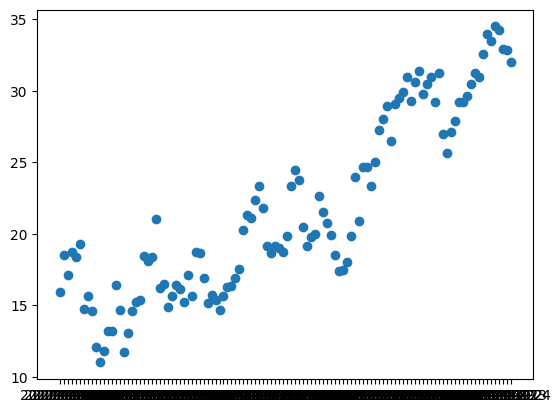

In [6]:
plt.scatter(df['date'], df['meantemp'])
plt.show()

In [7]:
x1 = df['meantemp'].ewm(alpha=1).mean()

In [8]:
x1

,meantemp
0,15.913043
1,18.500000
2,17.111111
3,18.700000
4,18.388889
...,...
109,34.500000
110,34.250000
111,32.900000
112,32.875000


In [9]:
df['ewm'] = x1

In [10]:
df.head()

,date,meantemp,ewm
0,2017-01-01,15.913043,15.913043
1,2017-01-02,18.500000,18.500000
2,2017-01-03,17.111111,17.111111
3,2017-01-04,18.700000,18.700000
4,2017-01-05,18.388889,18.388889


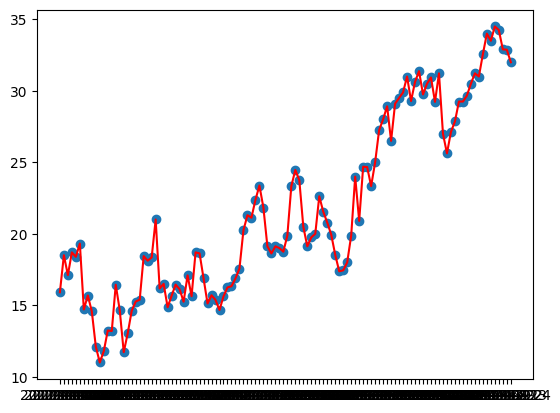

In [11]:
plt.scatter(df['date'],df['meantemp'])
plt.plot(x1, color='red')
plt.show()